Correlation (component 1): 0.475
Correlation (component 2): 0.042


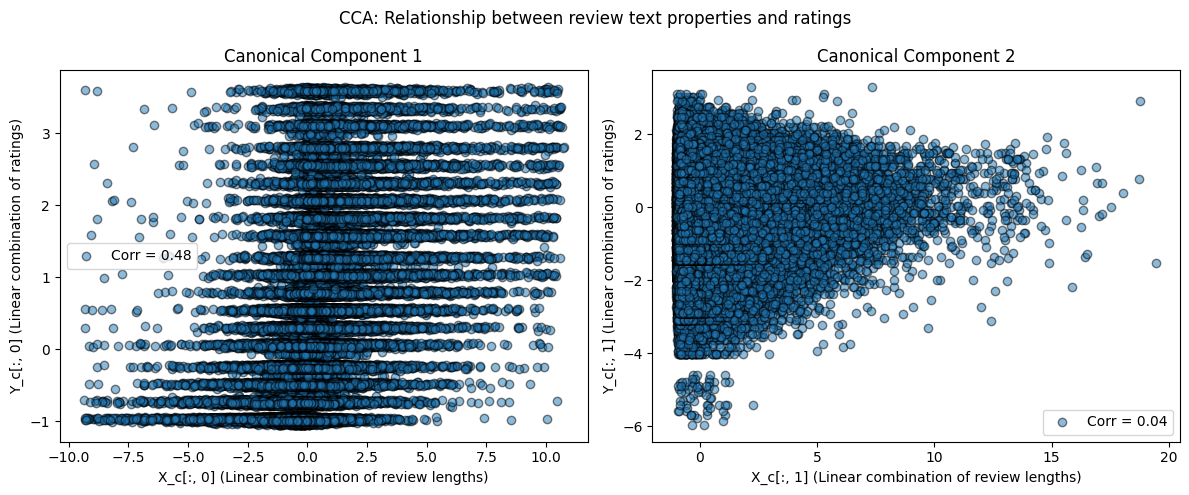

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import CCA
from sklearn.preprocessing import StandardScaler

def load_and_preprocess_data(csv_path: str = "hotels.csv") -> pd.DataFrame:
    
    """
    Loads and performs basic preprocessing of the dataset.
    Returns a cleaned DataFrame.
    """
    df = pd.read_csv("./Hotel_Reviews.csv", encoding="ISO-8859-1")
    
    df["Review_Date"] = pd.to_datetime(df["Review_Date"], errors="coerce")
    df.replace({"No Negative": np.nan, "No Positive": np.nan}, inplace=True)
    df["Neg_len"] = df["Negative_Review"].fillna("").apply(len)
    df["Pos_len"] = df["Positive_Review"].fillna("").apply(len)
    df.dropna(subset=["Reviewer_Score", "Average_Score", "Neg_len", "Pos_len"], inplace=True)
    return df

def run_cca_with_plots(df: pd.DataFrame):
    """
    Performs Canonical Correlation Analysis (CCA) on two sets of variables:
    X: [Neg_len, Pos_len] - properties of review texts
    Y: [Reviewer_Score, Average_Score] - rating indicators
    Plots two scatter plots for the two canonical components with descriptive labels.
    """
    X = df[["Neg_len", "Pos_len"]]
    Y = df[["Reviewer_Score", "Average_Score"]]
    scaler_X = StandardScaler()
    scaler_Y = StandardScaler()
    X_scaled = scaler_X.fit_transform(X)
    Y_scaled = scaler_Y.fit_transform(Y)
    cca = CCA(n_components=2)
    X_c, Y_c = cca.fit_transform(X_scaled, Y_scaled)
    corr_comp1 = np.corrcoef(X_c[:, 0], Y_c[:, 0])[0, 1]
    corr_comp2 = np.corrcoef(X_c[:, 1], Y_c[:, 1])[0, 1]
    print(f"Correlation (component 1): {corr_comp1:.3f}")
    print(f"Correlation (component 2): {corr_comp2:.3f}")
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].scatter(X_c[:, 0], Y_c[:, 0], alpha=0.5, edgecolors="k", label=f"Corr = {corr_comp1:.2f}")
    axes[0].set_title("Canonical Component 1")
    axes[0].set_xlabel("X_c[:, 0] (Linear combination of review lengths)")
    axes[0].set_ylabel("Y_c[:, 0] (Linear combination of ratings)")
    axes[0].legend()
    axes[1].scatter(X_c[:, 1], Y_c[:, 1], alpha=0.5, edgecolors="k", label=f"Corr = {corr_comp2:.2f}")
    axes[1].set_title("Canonical Component 2")
    axes[1].set_xlabel("X_c[:, 1] (Linear combination of review lengths)")
    axes[1].set_ylabel("Y_c[:, 1] (Linear combination of ratings)")
    axes[1].legend()
    plt.suptitle("CCA: Relationship between review text properties and ratings")
    plt.tight_layout()
    plt.show()

df = load_and_preprocess_data("hotels.csv")
run_cca_with_plots(df)